In [909]:
from IPython.display import HTML

HTML("""
<style>
.jp-CodeCell .jp-Cell-inputWrapper {
    display: none !important;
}

.jp-OutputPrompt,
.jp-InputPrompt {
    display: none !important;
}

.jp-RenderedHTMLCommon p {
    line-height: 1.3 !important;
    margin-top: 0.7em !important;
    margin-bottom: 0.7em !important;
}
</style>
""")

<div style="text-align: center; margin-top: 40px; margin-bottom: 45px;">

# Forecasting One-Month-Ahead S&P 500 Returns

### A Comparison of Macroeconomic Predictors and Regression Models

</div>

# Section 1: Introduction

This project examines whether macroeconomic indicators can improve one-month-ahead forecasts of S&P 500 returns using monthly data from 2000 to 2025. The forecasting target is the following month’s S&P 500 return.

An initial set of candidate predictors was collected from FRED, transformed using several methods, and adjusted for publication timing so that each forecast uses only information treated as available at the end of that month.

The predictors were assessed using stationarity tests, while correlation and variance inflation factor screening were conducted on the training set before a final set of six indicators was selected for modelling.

Forecasts were generated using a one-step-ahead forecasting procedure with a historical-mean benchmark, ordinary least squares, Ridge regression, and Lasso regression. Model performance was evaluated using RMSE, MAE, directional accuracy, and out-of-sample R², and robustness was checked across several train–test splits.

# Section 2: Data

In [ ]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

from fredapi import Fred

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.tsa.stattools import adfuller, kpss

from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

FRED_API_KEY = "FRED_API_KEY"
fred = Fred(api_key=FRED_API_KEY)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

START = "1999-01-01"   # pull a little before 2000 so lags/pct_change don't
                        # create NaNs at the very start of your real sample
END   = "2025-12-31"

## Data Sources and Candidate Predictors
Ten macroeconomic indicators were collected as the initial predictor set, alongside the S&P 500 return series used as the forecasting target.

| Variable | Source | FRED Series | Native Frequency |
|---|---|---|---|
| S&P 500 return | Yahoo Finance (`^GSPC`) | — | Daily → resampled monthly |
| CPI (inflation) | FRED | `CPIAUCSL` | Monthly |
| PPI | FRED | `PPIACO` | Monthly |
| M2 money supply | FRED | `M2SL` | Monthly |
| CapEx orders | FRED | `NEWORDER` | Monthly |
| Industrial production | FRED | `INDPRO` | Monthly |
| Unemployment rate | FRED | `UNRATE` | Monthly |
| Consumer sentiment | FRED | `UMCSENT` | Monthly |
| Federal funds rate | FRED | `FEDFUNDS` | Monthly |
| Term spread | FRED | `T10Y3M` | Daily → resampled monthly |
| Credit spread | FRED | `BAA, AAA` | Monthly |

## S&P 500 price and monthly return

This section downloads daily S&P 500 prices, smooths the closing price using a 5-day trailing average, and converts the series to monthly frequency using the final observation of each month. It then calculates monthly returns and creates the one-month-ahead return variable used as the forecasting target. Data was collected beginning in 1999 so that lagged variables and year-over-year percentage changes could be calculated without losing observations from the intended 2000–2025 sample.

Table showing head of the S&P 500 monthly dataset:

In [911]:
sp500_daily = yf.download("^GSPC",start=START, end=END, progress=False, auto_adjust=True)

# 5-day trailing average of daily close
sp500_5day_avg = sp500_daily["Close"].rolling(window=5).mean()

sp500_monthly = sp500_5day_avg.resample("ME").last()
sp500_monthly.name = "sp500_close_5day_avg"

sp500_ret = sp500_monthly.pct_change()
sp500_ret.name = "sp500_ret"

sp500_ret_next = sp500_ret.shift(-1)
sp500_ret_next.name = "sp500_ret_next"

sp500_df = pd.concat([sp500_monthly, sp500_ret, sp500_ret_next],axis=1)
sp500_df.columns = ["sp500_close_5day_avg","sp500_ret","sp500_ret_next"]

sp500_df.head()

,sp500_close_5day_avg,sp500_ret,sp500_ret_next
Date,,,
1999-01-31,1254.894019,NaN,0.000894
1999-02-28,1256.016016,0.000894,0.030254
1999-03-31,1294.016016,0.030254,0.043536
1999-04-30,1350.352026,0.043536,-0.040389
1999-05-31,1295.812012,-0.040389,0.032032


## Candidate Variable Downloads

Data for the ten candidate macroeconomic predictors were downloaded and aligned by date. The table provides a preview of the raw monthly data before any transformations or publication lags were applied.

In [912]:
fred_series = {
    "cpi": "CPIAUCSL",
    "unemployment": "UNRATE",
    "consumer_sentiment": "UMCSENT",
    "m2": "M2SL",
    "capex_orders": "NEWORDER",
    "indpro": "INDPRO",
    "fed_funds_rate": "FEDFUNDS",
    "ppi": "PPIACO",
    "term_spread": "T10Y3M",
    "baa_yield": "BAA",
    "aaa_yield": "AAA"
}

macro_raw = pd.DataFrame()

for variable_name, series_id in fred_series.items():
    macro_raw[variable_name] = fred.get_series(
        series_id,
        observation_start=START,
        observation_end=END
    )

# Term spread is daily, need to resample before aligning with monthly series
term_daily = fred.get_series("T10Y3M",observation_start=START,observation_end=END)

macro_raw.index.name = "date"

macro_raw.head().T.round(4)

date,1999-01-01,1999-02-01,1999-03-01,1999-04-01,1999-05-01
cpi,164.7000,164.700,164.8000,165.9000,166.0000
unemployment,4.3000,4.400,4.2000,4.3000,4.2000
consumer_sentiment,103.9000,108.100,105.7000,104.6000,106.8000
m2,4401.7000,4423.700,4430.1000,4459.9000,4487.9000
capex_orders,57160.0000,58576.000,59657.0000,58929.0000,59814.0000
indpro,87.4949,88.027,88.2267,88.4295,88.9886
fed_funds_rate,4.6300,4.760,4.8100,4.7400,4.7400
ppi,122.9000,122.300,122.6000,123.6000,124.7000
term_spread,NaN,0.220,0.6900,0.8300,NaN
baa_yield,7.2900,7.390,7.5300,7.4800,7.7200


## Predictor Transformations

The candidate variables were given  transformations based on their economic interpretation. CPI, PPI, M2 money supply, capital expenditures, industrial production, and consumer sentiment were converted to year-over-year percentage growth rates. The unemployment rate, federal funds rate, term spread, and credit spread were first-differenced.

Isolated one-month gaps were forward-filled using the most recently available observation. This avoids using future values when replacing missing data and keeps the preprocessing consistent with the forecasting setup.

These transformations were only an initial preprocessing step. No formal stationarity testing had been conducted at this stage, so the specifications shown here were not necessarily the final transformations used in the forecasting models.

The table below provides a preview of the monthly data after the preliminary growth and first-difference transformations were applied.

In [913]:
# Put monthly predictors on month-end dates
macro_monthly = macro_raw.drop(columns="term_spread").resample("ME").last()

# Aggregate the full daily term-spread series
macro_monthly["term_spread"] = term_daily.resample("ME").mean()

# Construct the credit spread
macro_monthly["credit_spread"] = (macro_monthly["baa_yield"] - macro_monthly["aaa_yield"])

# Create cleaned/transformed dataset
macro_clean = pd.DataFrame(index=macro_monthly.index)

# YoY percentage changes
macro_clean["cpi"] = macro_monthly["cpi"].pct_change(12, fill_method=None) * 100
macro_clean["ppi"] = macro_monthly["ppi"].pct_change(12, fill_method=None) * 100
macro_clean["m2"] = macro_monthly["m2"].pct_change(12, fill_method=None) * 100
macro_clean["consumer_sentiment"] = macro_monthly["consumer_sentiment"].pct_change(12, fill_method=None) * 100
macro_clean["capex_orders"] = macro_monthly["capex_orders"].pct_change(12, fill_method=None) * 100
macro_clean["indpro"] = macro_monthly["indpro"].pct_change(12, fill_method=None) * 100

# Take differences
macro_clean["unemployment"] = macro_monthly["unemployment"].diff()
macro_clean["fed_funds_rate"] = macro_monthly["fed_funds_rate"].diff()
macro_clean["term_spread"] = macro_monthly["term_spread"].diff()
macro_clean["credit_spread"] = macro_monthly["credit_spread"].diff()    

# Fill isolated missing monthly observations
macro_clean = macro_clean.ffill(limit=1)

# Drop only any remaining missing rows, usually at the start of the sample
macro_clean = macro_clean.dropna()

macro_clean.head().T.round(4)

date,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31
cpi,2.7930,3.2180,3.7621,3.0139,3.1325
ppi,4.3938,6.1325,6.6884,5.7443,5.5333
m2,6.0068,5.7644,6.2978,6.8724,6.0073
consumer_sentiment,7.7960,2.9602,1.3245,4.3977,3.6517
capex_orders,11.9227,-0.1349,6.6799,9.3078,6.5854
indpro,4.6210,4.3133,4.4473,4.8280,4.4515
unemployment,0.0000,0.1000,-0.1000,-0.2000,0.2000
fed_funds_rate,0.1500,0.2800,0.1200,0.1700,0.2500
term_spread,0.2434,-0.3695,-0.3999,-0.2237,0.2770
credit_spread,-0.0900,0.0600,0.0800,0.0700,0.1500


## Merging Dataframes

The transformed macroeconomic indicators were merged with the S&P 500 dataset using their shared monthly date index. Rows containing missing values were then removed to create a complete dataset for the subsequent variable-selection and forecasting analysis.

The table below previews the initial merged dataset, including the transformed predictors, the five-day average S&P 500 closing price, the monthly return, and the one-month-ahead return used as the forecasting target.

In [914]:
data = pd.concat([macro_clean, sp500_df], axis=1)

data = data.dropna()

data.head().T.round(4)

,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31
cpi,2.7930,3.2180,3.7621,3.0139,3.1325
ppi,4.3938,6.1325,6.6884,5.7443,5.5333
m2,6.0068,5.7644,6.2978,6.8724,6.0073
consumer_sentiment,7.7960,2.9602,1.3245,4.3977,3.6517
capex_orders,11.9227,-0.1349,6.6799,9.3078,6.5854
indpro,4.6210,4.3133,4.4473,4.8280,4.4515
unemployment,0.0000,0.1000,-0.1000,-0.2000,0.2000
fed_funds_rate,0.1500,0.2800,0.1200,0.1700,0.2500
term_spread,0.2434,-0.3695,-0.3999,-0.2237,0.2770
credit_spread,-0.0900,0.0600,0.0800,0.0700,0.1500


## Publication-Lag Treatment of Candidate Predictors

The publication lags below are separate from the one-month-ahead forecasting setup. The target variable is already defined as the S&P 500 return in month \(t+1\), while each row represents the information available by the end of month \(t\). These additional shifts account for whether a month-\(t\) observation was publicly available at the forecast date.

The timing adjustments are applied to all candidate predictors before calculating correlations, VIF values, and selecting the final predictor set.

| Variable | Data timing | Publication lag applied | Reason |
|---|---|---:|---|
| CPI | The month-\(t\) observation is released during month \(t+1\) | 1 month | The month-\(t\) value is not known by the end of month \(t\) |
| PPI | The month-\(t\) observation is released during month \(t+1\) | 1 month | The month-\(t\) value is not known by the end of month \(t\) |
| M2 money supply | The month-\(t\) observation is released during month \(t+1\) | 1 month | The month-\(t\) value is not known by the end of month \(t\) |
| CapEx orders | The month-\(t\) observation is released during month \(t+1\) | 1 month | The month-\(t\) value is not known by the end of month \(t\) |
| Industrial production | The month-\(t\) observation is released during month \(t+1\) | 1 month | The month-\(t\) value is not known by the end of month \(t\) |
| Unemployment rate | The month-\(t\) observation is released during month \(t+1\) | 1 month | The month-\(t\) value is not known by the end of month \(t\) |
| Consumer sentiment | Preliminary and final readings are released during the reference month | 1 month | A conservative lag avoids relying on preliminary or revised within-month information |
| Federal funds rate | The underlying daily effective federal funds rate is observed during month \(t\) | None | The month-\(t\) value is known by the end of month \(t\) |
| Term spread | Constructed from daily Treasury yields available during month \(t\) | None | The monthly average through the end of month \(t\) is known at the forecast date |
| Credit spread | Constructed from monthly Baa and Aaa corporate-yield series | 1 month | The monthly observation is treated conservatively as unavailable until the following month |

Therefore, CPI, PPI, M2, CapEx orders, industrial production, unemployment, consumer sentiment, and the credit spread are shifted by one month. The federal funds rate and term spread are left unshifted because their underlying market information is available by month-end. The resulting aligned predictors are then used to examine correlations with the S&P 500 return in the following month.

In [915]:
# Apply publication lags to candidate predictors

data["cpi"] = data["cpi"].shift(1)
data["ppi"] = data["ppi"].shift(1)
data["m2"] = data["m2"].shift(1)
data["capex_orders"] = data["capex_orders"].shift(1)
data["indpro"] = data["indpro"].shift(1)
data["unemployment"] = data["unemployment"].shift(1)
data["consumer_sentiment"] = data["consumer_sentiment"].shift(1)
data["credit_spread"] = data["credit_spread"].shift(1)

# No publication lag
# data["fed_funds_rate"] stays unchanged
# data["term_spread"] stays unchanged

data = data.dropna()

data.head().T.round(4)

,2000-02-29,2000-03-31,2000-04-30,2000-05-31,2000-06-30
cpi,2.7930,3.2180,3.7621,3.0139,3.1325
ppi,4.3938,6.1325,6.6884,5.7443,5.5333
m2,6.0068,5.7644,6.2978,6.8724,6.0073
consumer_sentiment,7.7960,2.9602,1.3245,4.3977,3.6517
capex_orders,11.9227,-0.1349,6.6799,9.3078,6.5854
indpro,4.6210,4.3133,4.4473,4.8280,4.4515
unemployment,0.0000,0.1000,-0.1000,-0.2000,0.2000
fed_funds_rate,0.2800,0.1200,0.1700,0.2500,0.2600
term_spread,-0.3695,-0.3999,-0.2237,0.2770,-0.2105
credit_spread,-0.0900,0.0600,0.0800,0.0700,0.1500


The table below shows the predictor values available at each month-end after accounting for publication timing. These values are used to forecast the following month’s S&P 500 return.

## Stationarity and Predictor Screening

The candidate predictors were tested for stationarity using the Augmented Dickey–Fuller (ADF) and KPSS tests. The table below reports the p-values and stationarity conclusions from both tests for each variable.

In [916]:
predictors = [
    "cpi",
    "ppi",
    "m2",
    "capex_orders",
    "indpro",
    "unemployment",
    "consumer_sentiment",
    "fed_funds_rate",
    "term_spread",
    "credit_spread"
]

stationarity_results = []

for variable in predictors:
    series = data[variable].dropna()

    adf_result = adfuller(series, autolag="AIC")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_result = kpss(
            series,
            regression="c",
            nlags="auto"
        )

    stationarity_results.append({
        "variable": variable,
        "ADF p-value": adf_result[1],
        "KPSS p-value": kpss_result[1],
        "ADF conclusion": (
            "Stationary" if adf_result[1] < 0.05 else "Non-stationary"
        ),
        "KPSS conclusion": (
            "Stationary" if kpss_result[1] > 0.05 else "Non-stationary"
        )
    })

stationarity_results = pd.DataFrame(stationarity_results)

stationarity_results

,variable,ADF p-value,KPSS p-value,ADF conclusion,KPSS conclusion
0,cpi,2.647465e-02,0.1,Stationary,Stationary
1,ppi,1.134225e-04,0.1,Stationary,Stationary
2,m2,6.496385e-03,0.1,Stationary,Stationary
3,capex_orders,5.390194e-04,0.1,Stationary,Stationary
4,indpro,4.724559e-03,0.1,Stationary,Stationary
5,unemployment,1.919731e-18,0.1,Stationary,Stationary
6,consumer_sentiment,3.058016e-03,0.1,Stationary,Stationary
7,fed_funds_rate,1.067492e-03,0.1,Stationary,Stationary
8,term_spread,1.360527e-13,0.1,Stationary,Stationary
9,credit_spread,1.919805e-19,0.1,Stationary,Stationary


All predictor variables are classified as stationary under both the ADF and KPSS tests. These transformed series are therefore retained for the subsequent predictor-screening and forecasting analysis.

## Final Variable Transformations

The table below summarizes the transformation applied to each predictor. It also provides a brief interpretation of what each transformed variable represents in the forecasting dataset.
| Variable | Transformation used | Interpretation |
|---|---|---|
| CPI | Year-over-year percentage growth | Annual CPI inflation rate |
| PPI | Year-over-year percentage growth | Annual producer-price inflation rate |
| M2 money supply | Year-over-year percentage growth | Annual growth in the money supply |
| CapEx orders | Year-over-year percentage growth | Annual growth in new capital-goods orders |
| Industrial production | Year-over-year percentage growth | Annual growth in industrial production |
| Consumer sentiment | Year-over-year percentage growth | Annual growth in the consumer sentiment index |
| Unemployment rate | First difference | Monthly change in unemployment rate |
| Federal funds rate | First difference | Monthly change in effective federal funds rate |
| Term spread | First difference | Monthly change in the 10-year minus 3-month Treasury spread |
| Credit spread | First difference | Monthly change in the difference between Baa and Aaa corporate bond yields |

# Section 3: Predictor Screening and Selection

## Correlation Screening

The correlations between each transformed predictor and the one-month-ahead S&P 500 return were calculated using only the initial training sample. Restricting the screening to the training sample prevents the testing period from influencing variable selection and provides a more credible measure of out-of-sample performance. The results are ordered by absolute correlation so that the predictors with the strongest individual relationships with next-month returns appear first.

In [917]:
screen_split_index = int(len(data) * 0.60)
screening_data = data.iloc[:screen_split_index]

correlations = (
    screening_data[predictors]
    .corrwith(screening_data["sp500_ret_next"])
    .sort_values(key=abs, ascending=False)
)

correlations

cpi                  -0.227385
credit_spread        -0.207904
ppi                  -0.177276
fed_funds_rate        0.171603
unemployment         -0.152950
consumer_sentiment    0.136984
term_spread          -0.063341
capex_orders          0.025722
indpro                0.025237
m2                    0.019369
dtype: float64

Overall, the correlations are weak. CPI and PPI have the largest absolute correlations, while consumer sentiment and capital expenditures have relationships close to zero. Correlation is used only as an initial screening tool and does not by itself establish that a variable will improve out-of-sample forecasts.

## VIF Analysis

Variance inflation factors were calculated for the full set of candidate predictors to identify variables containing highly overlapping information. A high VIF indicates that a predictor is strongly related to other predictors, which can make regression coefficients unstable.

In [918]:
X = screening_data[predictors].dropna()

X_with_constant = add_constant(X)

vif_results = pd.DataFrame({
    "variable": X_with_constant.columns,
    "VIF": [
        variance_inflation_factor(X_with_constant.values, i)
        for i in range(X_with_constant.shape[1])
    ]
})

vif_results = (
    vif_results
    .query("variable != 'const'")
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

vif_results

,variable,VIF
0,ppi,10.241449
1,cpi,6.085652
2,capex_orders,5.445323
3,indpro,3.793871
4,consumer_sentiment,2.206676
5,m2,2.082070
6,fed_funds_rate,1.896380
7,unemployment,1.618743
8,term_spread,1.446829
9,credit_spread,1.260863


The final predictor set consists of CPI, industrial production, the term spread, the credit spread, the unemployment rate, and the federal funds rate. Predictor selection combined the correlation and VIF results with economic intuition about inflation, economic activity, monetary policy, and financial conditions.

In [919]:
final_predictors = [
    "cpi",
    "fed_funds_rate",
    "indpro",
    "term_spread",
    "unemployment",
    "credit_spread"
]

X_final = screening_data[final_predictors].dropna()
X_final_constant = add_constant(X_final)

final_vif = pd.DataFrame({
    "variable": X_final_constant.columns,
    "VIF": [
        variance_inflation_factor(X_final_constant.values, i)
        for i in range(X_final_constant.shape[1])
    ]
})

final_vif = (
    final_vif
    .query("variable != 'const'")
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

final_vif

,variable,VIF
0,indpro,1.923581
1,fed_funds_rate,1.652347
2,unemployment,1.494460
3,term_spread,1.434022
4,cpi,1.393221
5,credit_spread,1.202634


The VIF values were then recalculated for the final predictor set. All six values are low, indicating that the retained predictors do not create a meaningful multicollinearity problem.

## Final Predictor Set

The final modelling dataset contains the six predictors used in the forecasting models: CPI, industrial production, the term spread, the credit spread, the unemployment rate, and the federal funds rate. These variables are combined with the one-month-ahead S&P 500 return, which serves as the forecasting target.

The table below previews the completed dataset that will be used to estimate and evaluate the forecasting models.

In [920]:
model_data = data[
    final_predictors + ["sp500_ret_next"]
].dropna()

model_data.head()

,cpi,fed_funds_rate,indpro,term_spread,unemployment,credit_spread,sp500_ret_next
2000-02-29,2.792957,0.28,4.620955,-0.369500,0.0,-0.09,0.113083
2000-03-31,3.217972,0.12,4.313336,-0.399891,0.1,0.06,-0.032016
2000-04-30,3.762136,0.17,4.447293,-0.223661,-0.1,0.08,-0.038981
2000-05-31,3.013864,0.25,4.828027,0.276962,-0.2,0.07,0.036567
2000-06-30,3.132530,0.26,4.451469,-0.210455,0.2,0.15,-0.004194


# Section 4: Summary Statistics

## Descriptive Statistics Table

The table below summarizes the final predictors and the one-month-ahead S&P 500 return using the number of observations, mean, standard deviation, minimum, quartiles, and maximum. These statistics provide an initial comparison of each variable’s typical value, variability, and overall range before the forecasting models are estimated.

In [921]:
variable_labels = {
    "cpi": "CPI Inflation (YoY %)",
    "indpro": "Industrial Production Growth (YoY %)",
    "term_spread": "Change in Term Spread (Percentage Points)",
    "credit_spread": "Change in Credit Spread (Percentage Points)",
    "unemployment": "Change in Unemployment Rate (Percentage Points)",
    "fed_funds_rate": "Change in Federal Funds Rate (Percentage Points)",
    "sp500_ret_next": "Next-Month S&P 500 Return (Decimal)"
}

summary_stats = (
    model_data.describe().T[
        ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
    ]
    .rename(index=variable_labels)
    .rename(columns={
        "count": "N",
        "mean": "Mean",
        "std": "Std. Dev.",
        "min": "Minimum",
        "25%": "25th Percentile",
        "50%": "Median",
        "75%": "75th Percentile",
        "max": "Maximum"
    })
    .round(4)
)

summary_stats

,N,Mean,Std. Dev.,Minimum,25th Percentile,Median,75th Percentile,Maximum
CPI Inflation (YoY %),309.0,2.5824,1.7382,-1.9588,1.6406,2.3321,3.3159,8.9794
Change in Federal Funds Rate (Percentage Points),309.0,-0.0044,0.1828,-0.9600,-0.0100,0.0000,0.0200,0.7000
Industrial Production Growth (YoY %),309.0,0.5672,4.2823,-17.3183,-0.9971,1.6574,2.9076,16.5521
Change in Term Spread (Percentage Points),309.0,-0.0035,0.2420,-1.0068,-0.1546,-0.0165,0.1199,0.8250
Change in Unemployment Rate (Percentage Points),309.0,0.0013,0.6475,-2.2000,-0.1000,0.0000,0.1000,10.4000
Change in Credit Spread (Percentage Points),309.0,-0.0001,0.1174,-0.6300,-0.0500,-0.0100,0.0400,0.9400
Next-Month S&P 500 Return (Decimal),309.0,0.0062,0.0436,-0.2106,-0.0183,0.0122,0.0335,0.1223


The variables differ noticeably in scale and variability. CPI inflation and the unemployment rate show particularly wide ranges, while changes in the term spread are centered close to zero. The average next-month S&P 500 return is positive, but its minimum and maximum show that monthly returns can vary substantially.

## Distribution of Next-Month S&P 500 Returns

The histogram below shows the distribution of the one-month-ahead S&P 500 return used as the forecasting target. The dashed vertical line marks the average return and provides a reference point for the historical-mean benchmark used later in the analysis.

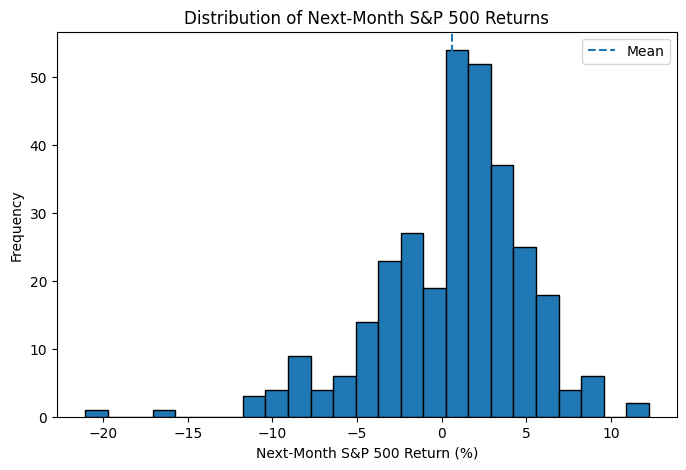

In [922]:
plt.figure(figsize=(8, 5))

plt.hist(
    model_data["sp500_ret_next"] * 100,
    bins=25,
    edgecolor="black"
)

plt.axvline(
    model_data["sp500_ret_next"].mean() * 100,
    linestyle="--",
    linewidth=1.5,
    label="Mean"
)

plt.xlabel("Next-Month S&P 500 Return (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Next-Month S&P 500 Returns")
plt.legend()

plt.show()

The distribution of next-month S&P 500 returns is centered slightly above zero, with most observations falling between roughly −5% and 5%. The distribution is negatively skewed because of a small number of large negative returns, including one extreme observation near −20%. Positive returns occur more frequently than negative returns, which helps explain why the historical-mean benchmark achieves relatively high directional accuracy despite making fairly simple forecasts.

# Section 5: Model Estimation and Evaluation

The forecasting models are evaluated using 60/40, 70/30, and 80/20 chronological train–test splits. OLS, Ridge, and Lasso are re-estimated each month using the most recent 120 months, while the historical-mean benchmark uses all previously observed returns. Performance is compared using RMSE, MAE, directional accuracy, and out-of-sample $R^2$ across the three testing periods.

In [924]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

ridge_alphas = np.logspace(-4, 4, 20)
lasso_alphas = np.logspace(-6, 0, 20)

split_ratios = [0.60, 0.70, 0.80]
window = 120

# Within each 120-month window:
# train on 84, 96, and 108 months; validate on the next 12 months
time_cv = TimeSeriesSplit(n_splits=3, test_size=12)

split_labels = {
    0.60: "60/40",
    0.70: "70/30",
    0.80: "80/20"
}

robustness_results = []


def evaluate_forecasts(actual, forecasts, benchmark):
    rmse = np.sqrt(mean_squared_error(actual, forecasts))
    mae = mean_absolute_error(actual, forecasts)

    directional_accuracy = (
        np.sign(forecasts) == np.sign(actual)
    ).mean()

    oos_r2 = 1 - (
        np.sum((actual - forecasts) ** 2)
        / np.sum((actual - benchmark) ** 2)
    )

    return rmse, mae, directional_accuracy, oos_r2


for split_ratio in split_ratios:
    robust_split_index = int(len(model_data) * split_ratio)

    if robust_split_index < window:
        raise ValueError(
            f"{split_labels[split_ratio]} split has fewer than "
            f"{window} training observations."
        )

    robust_test_data = model_data.iloc[robust_split_index:]
    robust_y_test = robust_test_data["sp500_ret_next"]

    robust_benchmark_forecasts = []
    robust_ols_forecasts = []
    robust_ridge_forecasts = []
    robust_lasso_forecasts = []

    for i in range(len(robust_test_data)):
        end = robust_split_index + i

        # Benchmark: average of all previously observed returns
        expanding_data = model_data.iloc[:end]

        robust_benchmark_forecasts.append(
            expanding_data["sp500_ret_next"].mean()
        )

        # Regression models: most recent 120 observations
        rolling_data = model_data.iloc[end - window:end]

        X_rolling = rolling_data[final_predictors]
        y_rolling = rolling_data["sp500_ret_next"]

        next_X = robust_test_data[final_predictors].iloc[[i]]

        # OLS
        ols_model = LinearRegression()
        ols_model.fit(X_rolling, y_rolling)

        robust_ols_forecasts.append(
            ols_model.predict(next_X)[0]
        )

        # Ridge: select the penalty using chronological validation
        ridge_model = GridSearchCV(
            estimator=make_pipeline(
                StandardScaler(),
                Ridge()
            ),
            param_grid={"ridge__alpha": ridge_alphas},
            cv=time_cv,
            scoring="neg_mean_squared_error",
            n_jobs=-1
        )

        ridge_model.fit(X_rolling, y_rolling)

        robust_ridge_forecasts.append(
            ridge_model.predict(next_X)[0]
        )

        # Lasso: select the penalty using chronological validation
        lasso_model = GridSearchCV(
            estimator=make_pipeline(
                StandardScaler(),
                Lasso(max_iter=100000)
            ),
            param_grid={"lasso__alpha": lasso_alphas},
            cv=time_cv,
            scoring="neg_mean_squared_error",
            n_jobs=-1
        )
        lasso_model.fit(X_rolling, y_rolling)

        robust_lasso_forecasts.append(
            lasso_model.predict(next_X)[0]
        )

    # Align forecasts with this split's test dates
    forecast_index = robust_test_data.index

    robust_benchmark_forecasts = pd.Series(
        robust_benchmark_forecasts,
        index=forecast_index,
        name="benchmark_forecast"
    )

    robust_ols_forecasts = pd.Series(
        robust_ols_forecasts,
        index=forecast_index,
        name="ols_forecast"
    )

    robust_ridge_forecasts = pd.Series(
        robust_ridge_forecasts,
        index=forecast_index,
        name="ridge_forecast"
    )

    robust_lasso_forecasts = pd.Series(
        robust_lasso_forecasts,
        index=forecast_index,
        name="lasso_forecast"
    )

    # Save the 80/20 forecasts for the plotting cells
    if split_ratio == 0.80:
        y_test = robust_y_test.copy()
        benchmark_forecasts = robust_benchmark_forecasts.copy()
        ols_forecasts = robust_ols_forecasts.copy()
        ridge_forecasts = robust_ridge_forecasts.copy()
        lasso_forecasts = robust_lasso_forecasts.copy()

    # Evaluate every model for every split
    model_forecasts = {
        "Historical-Mean Benchmark": robust_benchmark_forecasts,
        "OLS": robust_ols_forecasts,
        "Ridge": robust_ridge_forecasts,
        "Lasso": robust_lasso_forecasts
    }

    for model_name, forecasts in model_forecasts.items():
        rmse, mae, directional_accuracy, oos_r2 = evaluate_forecasts(
            robust_y_test,
            forecasts,
            robust_benchmark_forecasts
        )

        robustness_results.append({
            "Train-Test Split": split_labels[split_ratio],
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "Directional Accuracy": directional_accuracy,
            "Out-of-Sample R²": oos_r2
        })


# Display results for all three splits
robustness_results = pd.DataFrame(robustness_results)

for split_name in ["60/40", "70/30", "80/20"]:
    print(f"\n{split_name} Train-Test Split")

    split_table = (
        robustness_results[
            robustness_results["Train-Test Split"] == split_name
        ]
        .set_index("Model")
        .drop(columns="Train-Test Split")
        .round(4)
    )

    display(split_table)


60/40 Train-Test Split


,RMSE,MAE,Directional Accuracy,Out-of-Sample R²
Model,,,,
Historical-Mean Benchmark,0.0434,0.0334,0.7016,0.0000
OLS,0.0610,0.0371,0.6210,-0.9739
Ridge,0.0436,0.0328,0.7016,-0.0088
Lasso,0.0438,0.0328,0.6774,-0.0175



70/30 Train-Test Split


,RMSE,MAE,Directional Accuracy,Out-of-Sample R²
Model,,,,
Historical-Mean Benchmark,0.0460,0.0361,0.7097,0.0000
OLS,0.0673,0.0405,0.6022,-1.1349
Ridge,0.0459,0.0349,0.7097,0.0040
Lasso,0.0462,0.0351,0.6774,-0.0075



80/20 Train-Test Split


,RMSE,MAE,Directional Accuracy,Out-of-Sample R²
Model,,,,
Historical-Mean Benchmark,0.0396,0.0326,0.6935,0.0000
OLS,0.0403,0.0317,0.6452,-0.0353
Ridge,0.0394,0.0316,0.6935,0.0146
Lasso,0.0399,0.0319,0.6452,-0.0153


The models use 120-month rolling training windows and are evaluated across three forecast starting points. Ridge achieves approximately 1.5% out-of-sample $R^2$ in the 80/20 split, but does not consistently outperform the historical-mean benchmark across all three splits.

## Visual Comparison of Model Forecasts

The first plot compares the actual one-month-ahead S&P 500 returns with the forecasts from OLS, Ridge, and Lasso over the test period. The second plot removes the actual return series and focuses only on the model forecasts, making it easier to compare how the three models differ in their predicted movements.

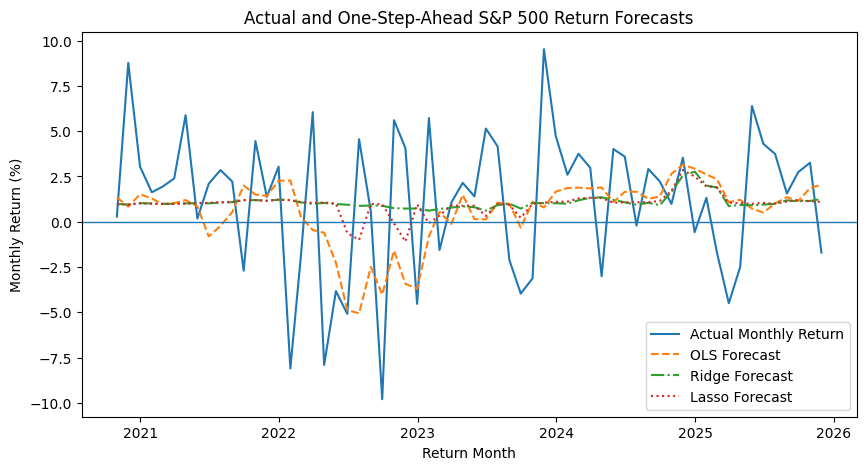

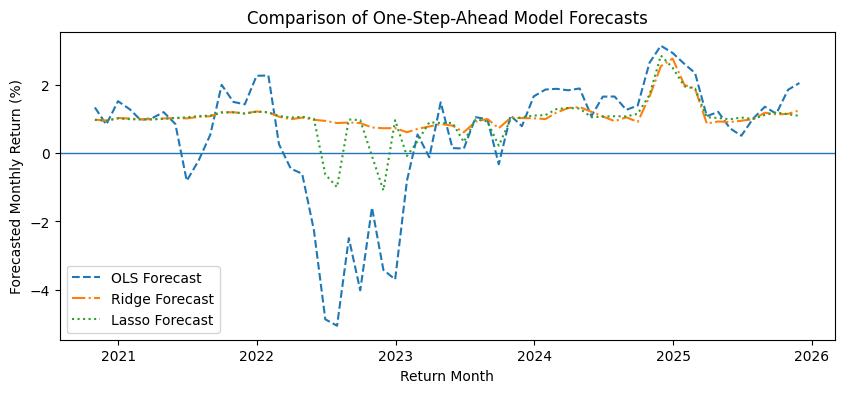

In [926]:
plot_dates = y_test.index + pd.offsets.MonthEnd(1)

# Actual returns and all model forecasts
plt.figure(figsize=(10, 5))

plt.plot(
    plot_dates,
    y_test * 100,
    label="Actual Monthly Return"
)

plt.plot(
    plot_dates,
    ols_forecasts * 100,
    label="OLS Forecast",
    linestyle="--"
)

plt.plot(
    plot_dates,
    ridge_forecasts * 100,
    label="Ridge Forecast",
    linestyle="-."
)

plt.plot(
    plot_dates,
    lasso_forecasts * 100,
    label="Lasso Forecast",
    linestyle=":"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Return Month")
plt.ylabel("Monthly Return (%)")
plt.title("Actual and One-Step-Ahead S&P 500 Return Forecasts")
plt.legend()
plt.show()


# Zoomed-in comparison of model forecasts
plt.figure(figsize=(10, 4))

plt.plot(
    plot_dates,
    ols_forecasts * 100,
    label="OLS Forecast",
    linestyle="--"
)

plt.plot(
    plot_dates,
    ridge_forecasts * 100,
    label="Ridge Forecast",
    linestyle="-."
)

plt.plot(
    plot_dates,
    lasso_forecasts * 100,
    label="Lasso Forecast",
    linestyle=":"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Return Month")
plt.ylabel("Forecasted Monthly Return (%)")
plt.title("Comparison of One-Step-Ahead Model Forecasts")
plt.legend()
plt.show()

The first figure shows that all three forecasting models produce much smoother predictions than the realized monthly S&P 500 returns. None of the models captures the large positive and negative movements observed during the test period, which is consistent with their weak out-of-sample performance.

The second figure highlights the differences across the model forecasts. OLS produces the most variable predictions and reacts most strongly to changes in the selected predictors. Ridge reduces some of this variation through coefficient shrinkage, while Lasso produces slightly smoother forecasts. Despite these differences, all three models fail to match the volatility of actual monthly returns, although Ridge slightly outperforms the historical-mean benchmark.

# Section 6: Discussion and Conclusion

The results differed across the models. In the 80/20 split, Ridge produced slightly lower forecast errors than the historical-mean benchmark, achieving approximately 1.5\% out-of-sample $R^2$. This was a modest improvement, while the other regression models did not show the same result. The forecast graphs also showed that none of the models captured the larger month-to-month movements in actual returns particularly well.

The robustness checks using alternative train–test splits showed that performance depended on the forecast starting point. Although Ridge slightly outperformed the benchmark in the 70/30 and 80/20 splits, it underperformed in the 60/40 split.

Overall, the selected macroeconomic indicators provided limited predictive value for monthly S&P 500 returns. The Ridge result shows that a small improvement over the historical mean is possible, but the results do not establish a consistent forecasting advantage.